**Question 1**<br>
Predict the marks of a student studing for 8 hours.

**Question 2**<br>
Will the Student Pass or Fail?

In [1]:
import pandas as pd

In [2]:
data = {
    'Hours_Studied': [2, 4, 6, 8, 10, 5, 7, 3, 9, 6],
    'Attendance': [75, 80, 85, 90, 95, 82, 88, 78, 92, 86],
    'Assignments': [4, 5, 6, 7, 8, 5, 6, 4, 7, 6],
    'Previous_Score': [32, 45, 58, 72, 88, 52, 68, 40, 80, 62],
    'Marks': [35,50,65,80,95,60,75,45,88,70],
}

In [3]:
df = pd.DataFrame(data)
df

,Hours_Studied,Attendance,Assignments,Previous_Score,Marks
0,2,75,4,32,35
1,4,80,5,45,50
2,6,85,6,58,65
3,8,90,7,72,80
4,10,95,8,88,95
5,5,82,5,52,60
6,7,88,6,68,75
7,3,78,4,40,45
8,9,92,7,80,88
9,6,86,6,62,70


In [4]:
df['Results'] =[1 if x >= 50 else 0 for x in df['Marks']]
df=df.drop(columns='Marks')
df

,Hours_Studied,Attendance,Assignments,Previous_Score,Results
0,2,75,4,32,0
1,4,80,5,45,1
2,6,85,6,58,1
3,8,90,7,72,1
4,10,95,8,88,1
5,5,82,5,52,1
6,7,88,6,68,1
7,3,78,4,40,0
8,9,92,7,80,1
9,6,86,6,62,1


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df[['Hours_Studied','Attendance','Assignments','Previous_Score']]
y = df['Results']

model = LogisticRegression()
model.fit(X,y)

LogisticRegression()

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Traning Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Traning Samples : 8
Testing Samples : 2


In [7]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
result = pd.DataFrame({'Actual Marks': y_test, 'Predicted Marks': y_pred})
result


Model Accuracy: 1.00


,Actual Marks,Predicted Marks
8,1,1
1,1,1


In [8]:
probability = model.predict_proba(X_test)
probability

array([[7.11208870e-13, 1.00000000e+00],
       [1.23584516e-01, 8.76415484e-01]])

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = df[['Hours_Studied','Attendance','Assignments','Previous_Score']]
y = df['Results']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Traning Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Traning Samples : 8
Testing Samples : 2


In [11]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
result = pd.DataFrame({'Actual Marks': y_test, 'Predicted Marks': y_pred})
result


Model Accuracy: 0.50


,Actual Marks,Predicted Marks
8,1,1
1,1,0


# Breast Cancer Wisconsin(Diagnostic)
|Property       |Value                |
|---------------|---------------------|
|Samples        |569                  |
|Features       |30                   |
|Classes        |2                    |
|Missing Values |None                 |
|Feature Type   |Numerical            |
|Problem Type   |Binary Classification|

In [12]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [13]:
import pandas as pd

df = pd.DataFrame(
    cancer.data,
    columns = cancer.feature_names
)

df['Target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Apply Logistic Regression


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Target')
y = df['Target']

scale = StandardScaler()

X = scale.fit_transform(X)

In [15]:
model = LogisticRegression()
model.fit(X,y)

LogisticRegression()

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Traning Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Traning Samples : 455
Testing Samples : 114


In [17]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
result = pd.DataFrame({'Actual Cancer': y_test, 'Predicted Cancer': y_pred})
result


Model Accuracy: 0.99


,Actual Cancer,Predicted Cancer
204,1,1
70,0,0
131,0,0
431,1,1
540,1,1
...,...,...
486,1,1
75,0,0
249,1,1
238,1,1


## Apply KNN

In [18]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Target')
y = df['Target']

scale = StandardScaler()

X = scale.fit_transform(X)

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Traning Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Traning Samples : 455
Testing Samples : 114


In [21]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
result = pd.DataFrame({'Actual Cancer': y_test, 'Predicted Cancer': y_pred})
result


Model Accuracy: 0.95


,Actual Cancer,Predicted Cancer
204,1,1
70,0,0
131,0,0
431,1,1
540,1,1
...,...,...
486,1,1
75,0,0
249,1,1
238,1,1


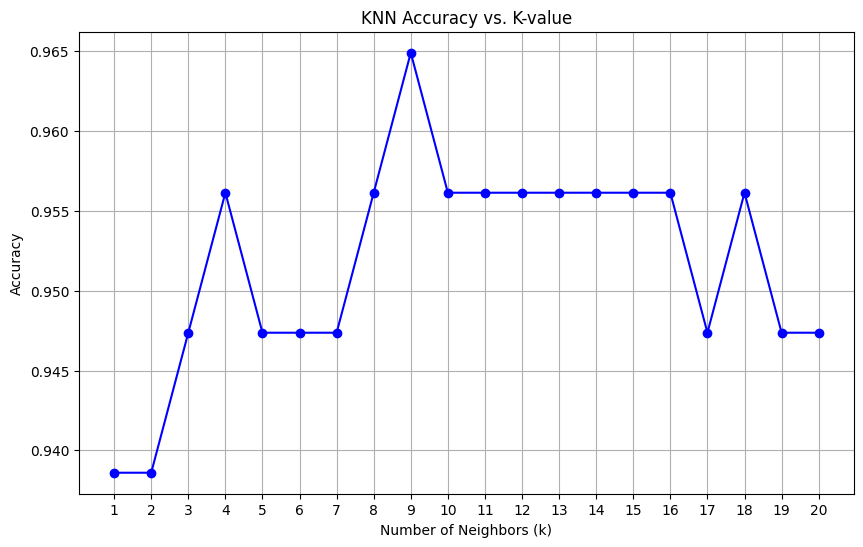


Best k value: 9 with accuracy: 0.9649


In [22]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21) # From 1 to 20 neighbors
accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_k = knn_model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='blue')
plt.title('KNN Accuracy vs. K-value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# Find the best k and its accuracy
best_k_index = accuracies.index(max(accuracies))
best_k = k_values[best_k_index]
best_accuracy = accuracies[best_k_index]

print(f"\nBest k value: {best_k} with accuracy: {best_accuracy:.4f}")